<a href="https://colab.research.google.com/github/amit-devs/ecommerce-recommendation-system-2/blob/main/KNN_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **KNN Collaborative Filtering Recommendation System**

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from google.colab import drive

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
path = '/content/drive/MyDrive/ml_tae/cleaned_products.csv'

df = pd.read_csv(path)

df.head()

,user_id,product_id,rating,product_name,brand_name,about_item,product_description,breadcrumbs,combined_text,weighted_rating
0,R199C1DG57O8P6,B07FMX9FSF,5.0,POLO RALPH LAUREN Men's Slim Fit Cotton Crew U...,POLO Store,"Length: 29.25in / 74cm, Chest: 41in / 104cm",POLO mens Polo Ralph Lauren Slim Fit Wicking C...,"Clothing, Shoes & Jewelry › Men › Clothing › U...",polo ralph lauren men's slim fit cotton crew u...,4.788114
1,R1UFTLDMUCDF0W,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
2,R12009XIWF7S1B,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
3,R30F5N17APS8XF,B07FMZ31SR,5.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.788114
4,R3M1U8JP4SQ93K,B07FMZ31SR,4.0,POLO RALPH LAUREN Men's Classic Fit Cotton V-N...,POLO Store,A quality Polo Ralph Lauren staple for your wa...,POLO Mens Classic Fit Cotton V neck Undershirt...,"Clothing, Shoes & Jewelry › Men › Clothing › S...",polo ralph lauren men's classic fit cotton v-n...,4.288114


In [5]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
df.info()

Dataset Shape: (2322, 10)

Columns:
Index(['user_id', 'product_id', 'rating', 'product_name', 'brand_name',
       'about_item', 'product_description', 'breadcrumbs', 'combined_text',
       'weighted_rating'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2322 entries, 0 to 2321
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   user_id              2322 non-null   object 
 1   product_id           2322 non-null   object 
 2   rating               2322 non-null   float64
 3   product_name         2322 non-null   object 
 4   brand_name           2322 non-null   object 
 5   about_item           2322 non-null   object 
 6   product_description  2322 non-null   object 
 7   breadcrumbs          2322 non-null   object 
 8   combined_text        2322 non-null   object 
 9   weighted_rating      2322 non-null   float64
dtypes: float64(2), object(8)
memory usage: 1

In [6]:
df_products = (
    df.sort_values("weighted_rating", ascending=False)
      .drop_duplicates(subset="product_id")
      .reset_index(drop=True)
)

print("Original Rows:", df.shape[0])
print("Product Level Rows:", df_products.shape[0])

Original Rows: 2322
Product Level Rows: 254


In [7]:
# Collaborative Filtering
user_item_matrix = df.pivot_table(
    index="product_id",
    columns="user_id",
    values="rating",
    fill_value=0
)

print(user_item_matrix.shape)

(254, 2322)


In [8]:
# KNN Model
knn_model = NearestNeighbors(
    metric="cosine",
    algorithm="brute"
)

knn_model.fit(user_item_matrix)

NearestNeighbors(algorithm='brute', metric='cosine')

In [9]:
def recommend_products(product_name, top_n=5):

    matches = df_products[
        df_products["product_name"].str.lower().str.contains(product_name.lower(), na=False)
    ]

    if matches.empty:
        print("Product not found.")
        return None

    product_row = matches.iloc[0]
    product_id = product_row["product_id"]
    category = product_row["breadcrumbs"]

    if product_id not in user_item_matrix.index:
        print("Product not in user-item matrix.")
        return None

    product_vector = user_item_matrix.loc[[product_id]]

    distances, indices = knn_model.kneighbors(product_vector, n_neighbors=top_n*10)

    same_category = []
    other_products = []

    for idx in indices.flatten():

        similar_product_id = user_item_matrix.index[idx]

        if similar_product_id == product_id:
            continue

        product_data = df_products[df_products["product_id"] == similar_product_id]

        if product_data.empty:
            continue

        product_info = product_data.iloc[0]

        if product_info["breadcrumbs"] == category:
            same_category.append(product_info)
        else:
            other_products.append(product_info)

    results = same_category[:top_n]

    if len(results) < top_n:
        remaining = top_n - len(results)
        results.extend(other_products[:remaining])

    results_df = pd.DataFrame(results)[
        ["product_name", "brand_name", "breadcrumbs", "weighted_rating"]
    ]

    return results_df.head(top_n)

Type here to **Search**

In [16]:
product = input("Enter product name: ")

recommendations = recommend_products(product)

print("\nRecommended Products:\n")

if recommendations is not None and len(recommendations) > 0:

    for _, row in recommendations.iterrows():

        print(
            f"{row['product_name']} | "
            f"{row['brand_name']} | "
            f"Rating: {round(row['weighted_rating'],2)}"
        )

else:
    print("No recommendations found.")

Enter product name: jeans

Recommended Products:

Levi's Men's 550 Relaxed Fit Jeans (Also Available in Big & Tall) | Levi's Store | Rating: 4.79
Levi's Men's 501 Original Fit Jeans (Also Available in Big & Tall) | Levi's Store | Rating: 4.79
Levi's Men's 541 Athletic Fit Jeans (Also Available in Big & Tall) | Levi's Store | Rating: 4.79
Levi's Men's 559 Relaxed Straight Jeans (Also Available in Big & Tall) | Levi's Store | Rating: 4.79
Levi Strauss Signature Gold Men's Carpenter Jeans | Levi Strauss Signature Gold Store | Rating: 4.79


In [17]:
def evaluate_results(results):

    merged = results.merge(
        df[["product_name","rating"]],
        on="product_name",
        how="left"
    )

    merged["rating"] = merged["rating"].fillna(0)

    merged["actual"] = merged["rating"].apply(lambda x: 1 if x >= 4 else 0)

    merged["predicted"] = 1

    y_true = merged["actual"]
    y_pred = merged["predicted"]

    accuracy = accuracy_score(y_true, y_pred) * 100
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    try:
        roc_auc = roc_auc_score(y_true, y_pred)
    except:
        roc_auc = 0

    cm = confusion_matrix(y_true, y_pred)

    print("\nModel Evaluation")
    print("------------------------")
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1 Score:", f1)
    print("ROC-AUC:", roc_auc)

    print("\nConfusion Matrix:")
    print(cm)

evaluate_results(recommendations)


Model Evaluation
------------------------
Accuracy: 84.0
Precision: 0.84
Recall: 1.0
F1 Score: 0.9130434782608695
ROC-AUC: 0.5

Confusion Matrix:
[[ 0  8]
 [ 0 42]]


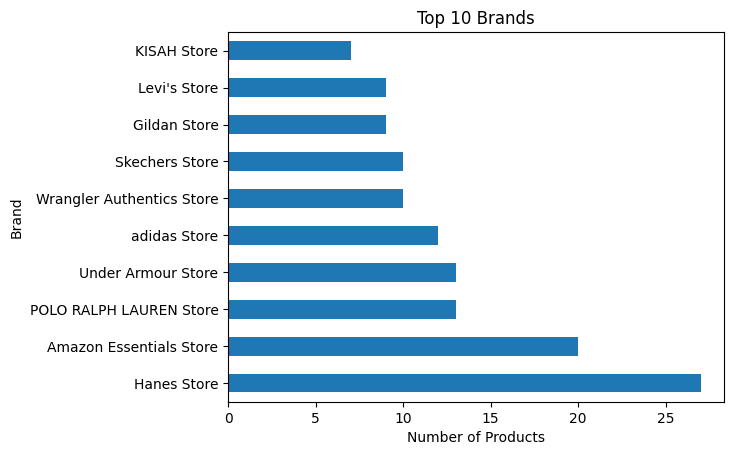

In [18]:
top_brands = df_products["brand_name"].value_counts().head(10)

plt.figure()

top_brands.plot(kind="barh")

plt.title("Top 10 Brands")
plt.xlabel("Number of Products")
plt.ylabel("Brand")

plt.show()

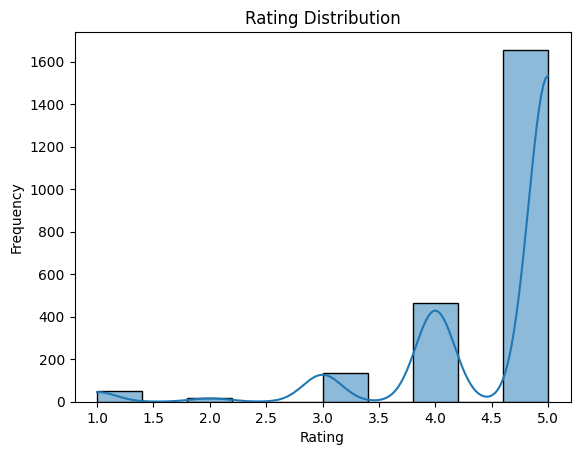

In [19]:
plt.figure()

sns.histplot(df["rating"], bins=10, kde=True)

plt.title("Rating Distribution")
plt.xlabel("Rating")
plt.ylabel("Frequency")

plt.show()